<a href="https://colab.research.google.com/github/Prakshil/ML_101/blob/main/CarPrice_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/quikr_car.csv')
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [ ]:
df.shape

(892, 6)

In [ ]:
df.describe()

,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [ ]:
df.sample(10)

,name,company,year,Price,kms_driven,fuel_type
346,Mahindra Xylo E4,Mahindra,2012,"4,00,000","35,000 kms",Diesel
706,Maruti Suzuki Swift Dzire VDi,Maruti,2016,"4,99,000","51,000 kms",Diesel
623,Tata Sumo Gold EX BS IV,Tata,2012,"2,10,000","75,000 kms",Diesel
299,Tata Indica V2 Xeta e GLE,Tata,2008,"1,50,000","11,000 kms",Petrol
689,Volkswagen Jetta Comfortline 1.9 TDI AT,Volkswagen,2009,"4,50,000","54,500 kms",Diesel
457,Hyundai Elite i20 Magna 1.2,Hyundai,2015,"4,05,000","28,000 kms",Petrol
696,BMW X1,BMW,2011,"10,00,000","34,000 kms",Diesel
651,Mahindra TUV300 T4 Plus,Mahindra,2016,"5,40,000","29,500 kms",Diesel
647,Hyundai Elite i20 Asta 1.2,Hyundai,2015,"5,00,000","22,000 kms",Petrol
740,Hyundai Santro Xing XL eRLX Euro III,Hyundai,2009,"88,000","43,200 kms",Petrol


In [ ]:
df.isnull().sum()

,0
name,0
company,0
year,0
Price,0
kms_driven,52
fuel_type,55


In [ ]:
df.isnull().sum().sum()

np.int64(107)

In [ ]:
df['year'].unique() ## There's Extra or random values in the dataset which needs to be removed or fixed

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [ ]:
df['Price'].unique() ## categorical values are there for price instead of integer and plus "Ask for price" entry

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [ ]:
df['kms_driven'].unique() ## integer values are not there and kms is not required in the data

array(['45,000 kms', '40 kms', '22,000 kms', '28,000 kms', '36,000 kms',
       '59,000 kms', '41,000 kms', '25,000 kms', '24,530 kms',
       '60,000 kms', '30,000 kms', '32,000 kms', '48,660 kms',
       '4,000 kms', '16,934 kms', '43,000 kms', '35,550 kms',
       '39,522 kms', '39,000 kms', '55,000 kms', '72,000 kms',
       '15,975 kms', '70,000 kms', '23,452 kms', '35,522 kms',
       '48,508 kms', '15,487 kms', '82,000 kms', '20,000 kms',
       '68,000 kms', '38,000 kms', '27,000 kms', '33,000 kms',
       '46,000 kms', '16,000 kms', '47,000 kms', '35,000 kms',
       '30,874 kms', '15,000 kms', '29,685 kms', '1,30,000 kms',
       '19,000 kms', nan, '54,000 kms', '13,000 kms', '38,200 kms',
       '50,000 kms', '13,500 kms', '3,600 kms', '45,863 kms',
       '60,500 kms', '12,500 kms', '18,000 kms', '13,349 kms',
       '29,000 kms', '44,000 kms', '42,000 kms', '14,000 kms',
       '49,000 kms', '36,200 kms', '51,000 kms', '1,04,000 kms',
       '33,333 kms', '33,600 kms', '5,

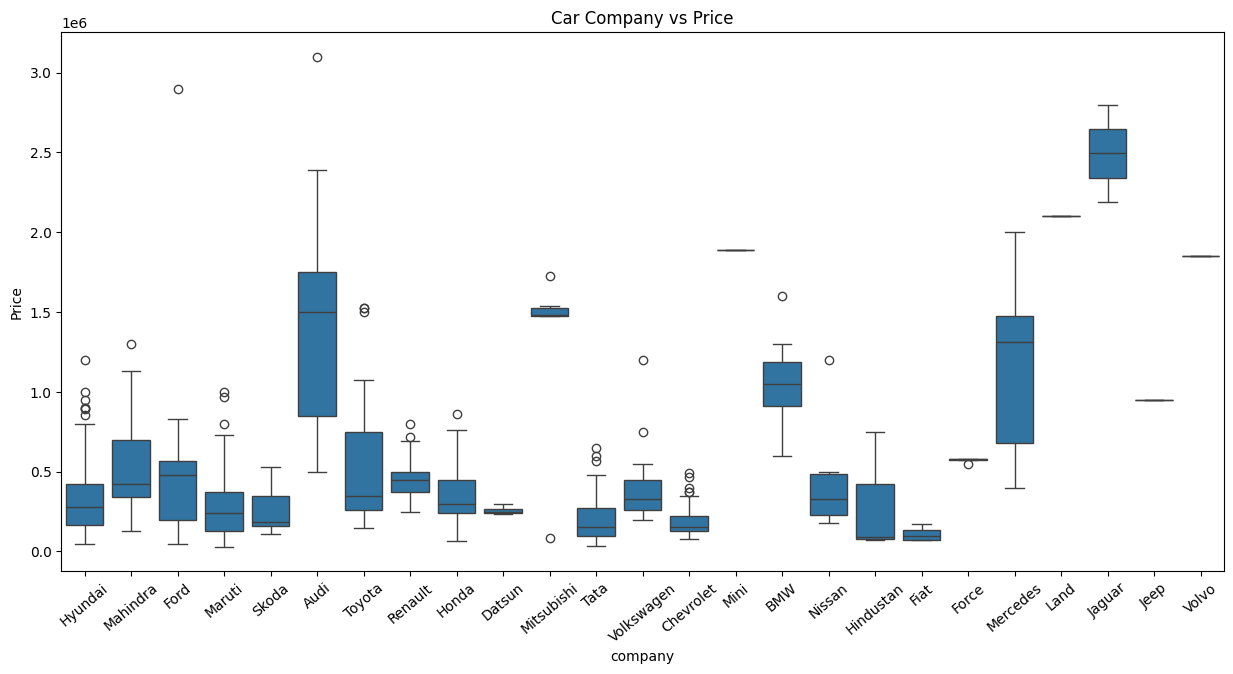

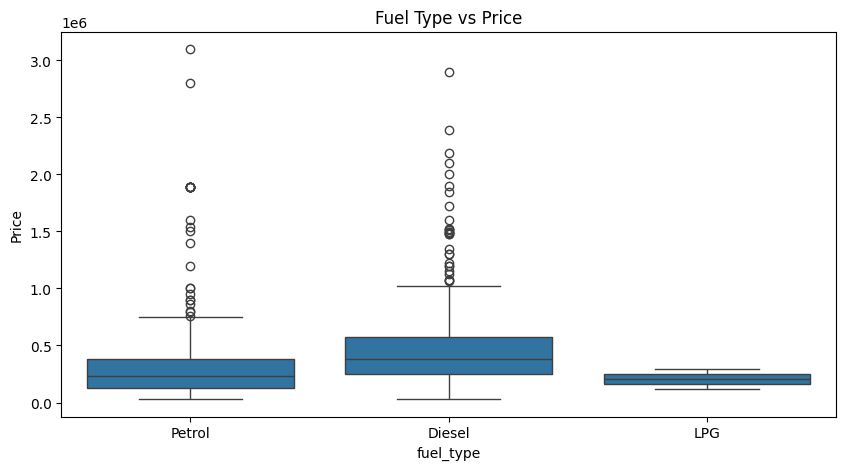

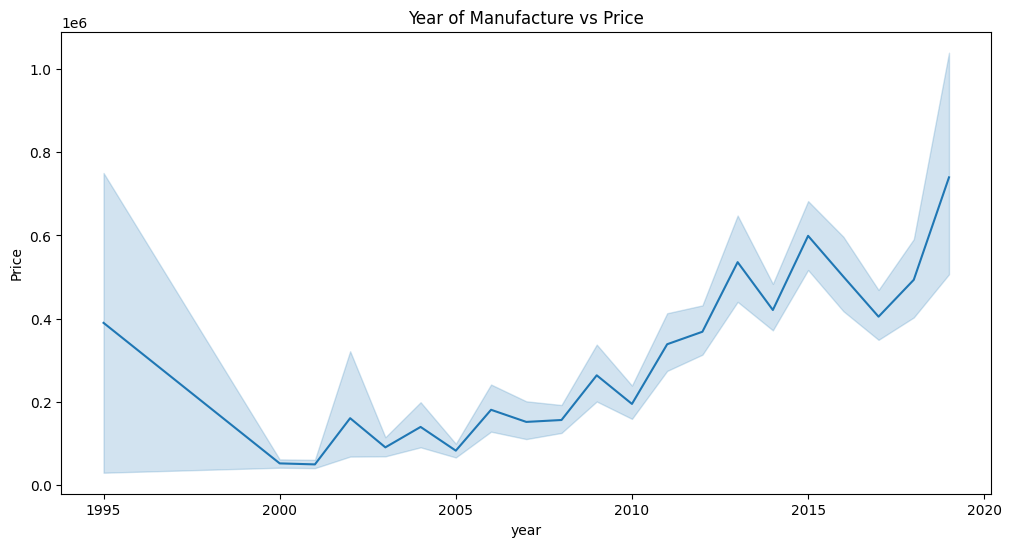

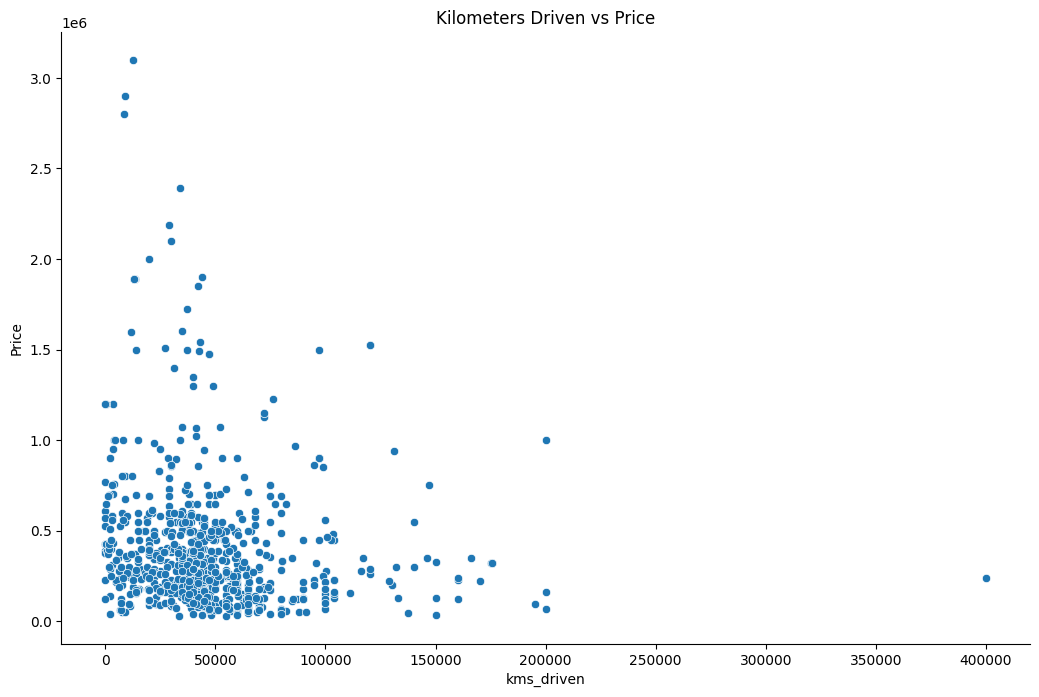

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))
sns.boxplot(x='company', y='Price', data=df)
plt.xticks(rotation=40)
plt.title('Car Company vs Price')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='fuel_type', y='Price', data=df)
plt.title('Fuel Type vs Price')
plt.show()

plt.figure(figsize=(12,6))
sns.lineplot(x='year', y='Price', data=df)
plt.title('Year of Manufacture vs Price')
plt.show()

sns.relplot(x='kms_driven', y='Price', data=df, height=7, aspect=1.5)
plt.title('Kilometers Driven vs Price')
plt.show()

In [ ]:
df['company'].unique() ## year , urgent , scratch any ,7,9 are the random or misbehaving vals in the column

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'I', 'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'MARUTI', 'Force', 'Mercedes', 'Land', 'Yamaha',
       'selling', 'URJENT', 'Swift', 'Used', 'Jaguar', 'Jeep', 'tata',
       'Sale', 'very', 'Volvo', 'i', '2012', 'Well', 'all', '7', '9',
       'scratch', 'urgent', 'sell', 'TATA', 'Any', 'Tara'], dtype=object)

In [ ]:
df['name'].unique() ## long and inconsitent values as entries which many lead to poor results while we use the column

array(['Hyundai Santro Xing XO eRLX Euro III', 'Mahindra Jeep CL550 MDI',
       'Maruti Suzuki Alto 800 Vxi',
       'Hyundai Grand i10 Magna 1.2 Kappa VTVT',
       'Ford EcoSport Titanium 1.5L TDCi', 'Ford Figo', 'Hyundai Eon',
       'Ford EcoSport Ambiente 1.5L TDCi',
       'Maruti Suzuki Alto K10 VXi AMT', 'Skoda Fabia Classic 1.2 MPI',
       'Maruti Suzuki Stingray VXi', 'Hyundai Elite i20 Magna 1.2',
       'Mahindra Scorpio SLE BS IV', 'Audi A8', 'Audi Q7',
       'Mahindra Scorpio S10', 'Maruti Suzuki Alto 800',
       'Hyundai i20 Sportz 1.2', 'Maruti Suzuki Alto 800 Lx',
       'Maruti Suzuki Vitara Brezza ZDi', 'Maruti Suzuki Alto LX',
       'Mahindra Bolero DI', 'Maruti Suzuki Swift Dzire ZDi',
       'Mahindra Scorpio S10 4WD', 'Maruti Suzuki Swift Vdi BSIII',
       'Maruti Suzuki Wagon R VXi BS III',
       'Maruti Suzuki Wagon R VXi Minor',
       'Toyota Innova 2.0 G 8 STR BS IV', 'Renault Lodgy 85 PS RXL',
       'Skoda Yeti Ambition 2.0 TDI CR 4x2',
       'Maru

In [ ]:
df2 = df.copy()

## Cleaning the Data

In [ ]:
df['year'].str.isnumeric()

,year
0,True
1,True
2,True
3,True
4,True
...,...
887,False
888,True
889,True
890,True


In [ ]:
invalid_rows = df[~df['year'].str.isnumeric()]
print(invalid_rows)

                                       name     company  year          Price  \
185  Commercial , DZire LDI, 2016, for sale  Commercial   ...  Ask For Price   
195                 Tata indigo ecs LX, 201        Tata  150k       1,50,000   
206                      MARUTI SUZUKI DESI      MARUTI  TOUR       4,00,000   
286  Commercial , DZire LDI, 2016, for sale  Commercial   ...  Ask For Price   
294                                    Yama      Yamaha  r 15         55,000   
360                          selling car Ta     selling  Zest  Ask For Price   
368                            Tata Zest 90        Tata  /-Rs  Ask For Price   
385           Maruti Suzuki Swift Dzire car      Maruti  sale       3,00,000   
395     Maruti Suzuki Swift Dzire Tour (Gat      Maruti  ara)       3,00,000   
401                                    URJE      URJENT  SELL       1,80,000   
414      Swift Dzire Tour 27 Dec 2016 Regis       Swift  tion       3,70,000   
432                             Tata zes

In [ ]:
print(len(invalid_rows))

50


In [ ]:
df = df[df['year'].str.isnumeric()]

In [ ]:
## df['year'] = df['year'].astype(int)

In [ ]:
df.loc[:, 'year'] = df['year'].astype(int)

In [ ]:
print(df[df['Price'] == "Ask For Price"])

                                          name     company  year  \
2                   Maruti Suzuki Alto 800 Vxi      Maruti  2018   
5             Ford EcoSport Titanium 1.5L TDCi        Ford  2015   
69             I want to sell my car Tata Zest           I  2017   
85             I want to sell my car Tata Zest           I  2017   
138                 Maruti Suzuki Alto 800 Lxi      Maruti  2018   
295                    Maruti Suzuki Swift LDi      Maruti  2010   
304                         Tata Indica eV2 LS        Tata  2017   
388                 Maruti Suzuki Alto 800 Lxi      Maruti  2018   
449     Maruti Suzuki Zen Estilo LXI Green CNG      Maruti  2011   
503                Hyundai Xcent Base 1.1 CRDi     Hyundai  2015   
511                        Hyundai Xcent S 1.2     Hyundai  2015   
524                        Toyota Innova 2.0 V      Toyota  2009   
567                         Datsun Go Plus T O      Datsun  2016   
613                 Mahindra KUV100 K8 D 6 STR  

In [ ]:
df = df[df['Price']!= "Ask For Price"]

In [ ]:
df['Price'].str.replace(",","")

,Price
0,80000
1,425000
3,325000
4,575000
6,175000
...,...
886,300000
888,260000
889,390000
890,180000


In [ ]:
df['Price'] = df['Price'].str.replace(",","").astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    object
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(1), object(5)
memory usage: 44.8+ KB


In [ ]:
df['kms_driven'].str.split(" ")

,kms_driven
0,"[45,000, kms]"
1,"[40, kms]"
3,"[28,000, kms]"
4,"[36,000, kms]"
6,"[41,000, kms]"
...,...
886,"[1,32,000, kms]"
888,"[27,000, kms]"
889,"[40,000, kms]"
890,[Petrol]


In [ ]:
df['kms_driven'].str.split(" ").str.get(0)

,kms_driven
0,"45,000"
1,40
3,"28,000"
4,"36,000"
6,"41,000"
...,...
886,"1,32,000"
888,"27,000"
889,"40,000"
890,Petrol


In [ ]:
df['kms_driven'].str.split(" ").str.get(0).str.replace(",","")

,kms_driven
0,45000
1,40
3,28000
4,36000
6,41000
...,...
886,132000
888,27000
889,40000
890,Petrol


In [ ]:
df['kms_driven'] = df['kms_driven'].str.split(" ").str.get(0).str.replace(",","")

In [ ]:
df = df[df['kms_driven'].str.isnumeric()]

In [ ]:
df['kms_driven'] = df['kms_driven'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    object
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.7+ KB


In [ ]:
df = df[~df['fuel_type'].isna()]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    object
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.6+ KB


In [ ]:
df['name'].str.split(' ').str.slice(0,3).str.join(' ')

,name
0,Hyundai Santro Xing
1,Mahindra Jeep CL550
3,Hyundai Grand i10
4,Ford EcoSport Titanium
6,Ford Figo
...,...
883,Maruti Suzuki Ritz
885,Tata Indica V2
886,Toyota Corolla Altis
888,Tata Zest XM


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    object
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.6+ KB


In [ ]:
df.reset_index()

,index,name,company,year,Price,kms_driven,fuel_type
0,0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
2,3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
3,4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
4,6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...,...
811,883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
812,885,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
813,886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,888,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [ ]:
df.reset_index(drop=True)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
812,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [ ]:
df[df['Price']>6e6]

,name,company,year,Price,kms_driven,fuel_type
562,Mahindra XUV500 W6,Mahindra,2014,8500003,45000,Diesel


In [ ]:
df = df[df['Price']<6e6]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 815 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        815 non-null    object
 1   company     815 non-null    object
 2   year        815 non-null    object
 3   Price       815 non-null    int64 
 4   kms_driven  815 non-null    int64 
 5   fuel_type   815 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.6+ KB


In [ ]:
df.reset_index(drop=True)


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
810,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
811,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
812,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
813,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [ ]:
df.to_csv('Cleaned_Car_data.csv')

In [ ]:
X = df.drop(columns='Price')
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
ohe = OneHotEncoder()
ohe.fit(X[['name', 'company', 'fuel_type']])

OneHotEncoder()

In [ ]:
from sklearn.compose import ColumnTransformer,make_column_transformer
from sklearn.pipeline import make_pipeline

In [ ]:
column_transf = make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name', 'company', 'fuel_type']),remainder = 'passthrough')

In [ ]:
lr = LinearRegression()

In [ ]:
pipe = make_pipeline(column_transf,lr)

In [ ]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet 40 TFSI',
       'Audi A4 1.8 TFSI Multitronic Premium Plus',
       'Audi A4 2.0 TDI 177bhp Premium', 'Audi A6 2.0 TDI Premium',
       'Audi A8', 'Audi Q3 2.0 TDI quattro Premium',
       'Audi Q5 2.0 TDI quattro Premium Plus', 'Audi Q7',
       'BMW 3 Series 320d...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.6303455185335676

In [ ]:
scores = []
for i in range(1000):
  X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
  lr=LinearRegression()
  pipe=make_pipeline(column_transf,lr)
  pipe.fit(X_train,y_train)
  y_pred=pipe.predict(X_test)
  scores.append(r2_score(y_test,y_pred))


In [ ]:
np.argmax(scores)

np.int64(636)

In [ ]:
scores[np.argmax(scores)]

0.8656074115232235

In [ ]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([466456.62550426])

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_transf,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

0.8656074115232235

In [ ]:
import pickle

In [ ]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [ ]:
pipe.predict(pd.DataFrame(columns=['name','company','year','kms_driven','fuel_type'],data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([461407.85513029])

In [ ]:
pipe.steps[0][1].transformers[0][1].categories[0]

array(['Audi A3 Cabriolet 40 TFSI',
       'Audi A4 1.8 TFSI Multitronic Premium Plus',
       'Audi A4 2.0 TDI 177bhp Premium', 'Audi A6 2.0 TDI Premium',
       'Audi A8', 'Audi Q3 2.0 TDI quattro Premium',
       'Audi Q5 2.0 TDI quattro Premium Plus', 'Audi Q7',
       'BMW 3 Series 320d Sedan', 'BMW 3 Series 320i',
       'BMW 5 Series 520d Sedan', 'BMW 5 Series 530i',
       'BMW 7 Series 740Li Sedan', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d xLine', 'Chevrolet Beat',
       'Chevrolet Beat Diesel', 'Chevrolet Beat LS Diesel',
       'Chevrolet Beat LS Petrol', 'Chevrolet Beat LT Diesel',
       'Chevrolet Beat LT Opt Diesel', 'Chevrolet Beat LT Petrol',
       'Chevrolet Beat PS Diesel', 'Chevrolet Cruze LTZ',
       'Chevrolet Cruze LTZ AT', 'Chevrolet Enjoy',
       'Chevrolet Enjoy 1.4 LS 8 STR', 'Chevrolet Sail 1.2 LS',
       'Chevrolet Sail UVA Petrol LT ABS', 'Chevrolet Spark',
       'Chevrolet Spark 1.0 LT', 'Chevrolet Spark LS 1.0',
       'Chevrolet Spar